**An Analysis of Black Friday Sales Data in USA - 2025**

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("A1. Assignment") \
    .getOrCreate()

In [3]:
from google.colab import files
uploaded = files.upload()


Saving retail_black_friday_sales_100k.csv to retail_black_friday_sales_100k.csv


In [5]:
df = spark.read.csv(
    "retail_black_friday_sales_100k.csv",
    header=True,
    inferSchema=True
)


In [11]:
df.printSchema()
df.show(10)

root
 |-- transaction_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- city: string (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- original_price: double (nullable = true)
 |-- discount_pct: integer (nullable = true)
 |-- final_price: double (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- purchase_amount: double (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- purchase_date: date (nullable = true)
 |-- purchase_hour: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_black_friday: integer (nullable = true)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+------

In [7]:
df.count()
df.groupBy("city").sum("purchase_amount").show()

+-------------+--------------------+
|         city|sum(purchase_amount)|
+-------------+--------------------+
|      Phoenix|  3526014.4299999997|
|       Dallas|   3547967.429999994|
|  Los Angeles|  3430433.0200000047|
|San Francisco|   3445376.299999996|
|      Chicago|   3512360.629999997|
|      Atlanta|   3618348.519999996|
|      Seattle|   3456842.390000004|
|      Houston|  3474957.4499999983|
|        Miami|  3566829.8000000003|
|     New York|    3546500.69999999|
+-------------+--------------------+



**Task 2 — Data Cleaning**

Identify missing values



In [10]:
df.filter(df.purchase_amount.isNull()).count()

0

**Task 03 - Exploratory Data Analysis (EDA)**

Summary statistics for numerical columns

In [13]:
# Summary statistics for numerical columns
df.describe().show()

+-------+--------------+-----------+---------+------+-------+----------------+----------+----------------+-----------------+------------------+------------------+------------------+-----------------+--------------+----------------+-------------------+-------------------+
|summary|transaction_id|customer_id|age_group|gender|   city|customer_segment|product_id|product_category|   original_price|      discount_pct|       final_price|          quantity|  purchase_amount|payment_method|   purchase_hour|         is_weekend|    is_black_friday|
+-------+--------------+-----------+---------+------+-------+----------------+----------+----------------+-----------------+------------------+------------------+------------------+-----------------+--------------+----------------+-------------------+-------------------+
|  count|        100000|     100000|   100000|100000| 100000|          100000|    100000|          100000|           100000|            100000|            100000|            100000|   

In [15]:
# GroupBy analysis: Total purchase amount by Gender

df.groupBy("gender").sum("purchase_amount").show()

+------+--------------------+
|gender|sum(purchase_amount)|
+------+--------------------+
|Female|1.1638931689999979E7|
| Other|1.1719413020000003E7|
|  Male| 1.176728595999994E7|
+------+--------------------+



In [16]:
# Sorting: Top 10 highest purchases

df.orderBy(df.purchase_amount.desc()).show(10)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|      T0006388|    C001139|    36-45|  Male|       Dallas|       Returning|     P3120|     Electronics|        2408.8|           5|    2288.36|       5|        11441.8|    Debit Card|   2025-11-29|            8|         1|              0|
|      T0034867|    C012695|    18-25|Fe

In [18]:
# Filtering: Analysis of customers in a specific Age group (e.g., 26-35)

df.filter(df.age_group == "26-35").show()

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|      T0000001|    C007297|    26-35|  Male|San Francisco|           Loyal|     P2713|        Footwear|        153.73|          35|      99.92|       1|          99.92|   Credit Card|   2025-12-01|            0|         0|              0|
|      T0000003|    C018025|    26-35|  

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
product_category_sales_df = spark.sql("SELECT product_category, SUM(purchase_amount) as Total_Sales FROM retail_black_friday_sales_100k GROUP BY product_category ORDER BY Total_Sales DESC")
category_data_pd = product_category_sales_df.toPandas()

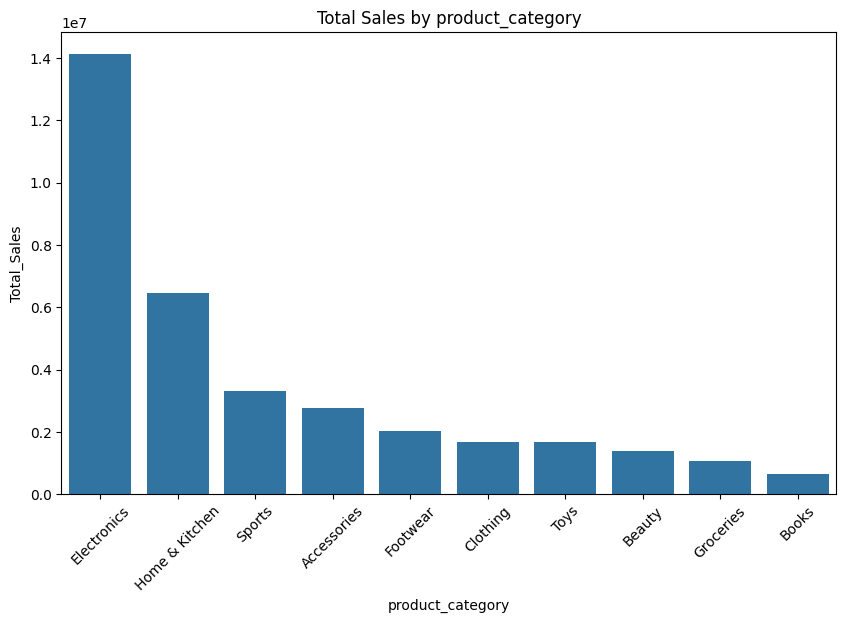

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(x='product_category', y='Total_Sales', data=category_data_pd)
plt.title('Total Sales by product_category')
plt.xticks(rotation=45)
plt.show()

**Task 4 — SQL Analysis**

In [20]:
# Create a temporary view

df.createOrReplaceTempView("retail_black_friday_sales_100k")


In [21]:
# 1. Top 5 highest transactions

spark.sql("SELECT * FROM retail_black_friday_sales_100k ORDER BY purchase_amount DESC LIMIT 5").show()

+--------------+-----------+---------+------+-------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|transaction_id|customer_id|age_group|gender|   city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|
+--------------+-----------+---------+------+-------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|      T0006388|    C001139|    36-45|  Male| Dallas|       Returning|     P3120|     Electronics|        2408.8|           5|    2288.36|       5|        11441.8|    Debit Card|   2025-11-29|            8|         1|              0|
|      T0034867|    C012695|    18-25|Female|Chicago|           

In [23]:
# 2. Average sales by Product ID

spark.sql("SELECT product_id, AVG(purchase_amount) as Avg_purchase_amount FROM retail_black_friday_sales_100k GROUP BY product_id").show()

+----------+-------------------+
|product_id|Avg_purchase_amount|
+----------+-------------------+
|     P6976|  691.3799999999999|
|     P4634|  763.1399999999999|
|     P5384|         444.518125|
|     P2949|  458.0683333333334|
|     P3024|  396.9023809523809|
|     P3122|  411.5033333333333|
|     P5100|  389.4852941176471|
|     P6207| 421.06812500000007|
|     P7769|  381.3646666666667|
|     P1670| 146.35166666666666|
|     P4489| 342.10999999999996|
|     P7303|          286.23125|
|     P1311|  519.0191666666667|
|     P5306| 226.15111111111113|
|     P1815| 469.41636363636366|
|     P3826|  398.6358333333333|
|     P7806|             296.32|
|     P2813|  588.6644444444445|
|     P5629|  313.8977777777778|
|     P2456|  639.9944444444444|
+----------+-------------------+
only showing top 20 rows


In [24]:
# 3. City-wise sales summary

spark.sql("SELECT city, SUM(purchase_amount) as Total_Sales FROM retail_black_friday_sales_100k GROUP BY city").show()

+-------------+------------------+
|         city|       Total_Sales|
+-------------+------------------+
|      Phoenix|3526014.4299999997|
|       Dallas| 3547967.429999994|
|  Los Angeles|3430433.0200000047|
|San Francisco| 3445376.299999996|
|      Chicago| 3512360.629999997|
|      Atlanta| 3618348.519999996|
|      Seattle| 3456842.390000004|
|      Houston|3474957.4499999983|
|        Miami|3566829.8000000003|
|     New York|  3546500.69999999|
+-------------+------------------+



Task 5 — Insights and Interpretation

Which product_categories perform best during Black Friday?

In [25]:
spark.sql("SELECT product_category, SUM(purchase_amount) as Total_Sales FROM retail_black_friday_sales_100k GROUP BY product_category ORDER BY Total_Sales DESC").show()

+----------------+--------------------+
|product_category|         Total_Sales|
+----------------+--------------------+
|     Electronics|1.4123441469999976E7|
|  Home & Kitchen|   6461099.920000016|
|          Sports|  3303563.2900000047|
|     Accessories|  2754561.5400000047|
|        Footwear|  2013317.3900000039|
|        Clothing|  1688471.8800000018|
|            Toys|  1669209.9099999978|
|          Beauty|  1374751.9700000016|
|       Groceries|   1075986.120000003|
|           Books|   661227.1800000027|
+----------------+--------------------+



Which customer_segments spend the most?

In [30]:
df.groupBy("customer_segment").sum("purchase_amount").show()

+----------------+--------------------+
|customer_segment|sum(purchase_amount)|
+----------------+--------------------+
|           Loyal|   8888416.699999968|
|       Returning|1.2125507739999983E7|
|             New|1.0574443419999978E7|
|             VIP|   3537262.809999996|
+----------------+--------------------+



What time of day drives the most purchases?

In [31]:
# Create a temporary view

df.createOrReplaceTempView("black_friday_sales")

# Run a SQL query


spark.sql("""
    SELECT purchase_hour, COUNT(*) as Total_Transactions
    FROM retail_black_friday_sales_100k
    GROUP BY purchase_hour
    ORDER BY Total_Transactions DESC
    LIMIT 1
""").show()

+-------------+------------------+
|purchase_hour|Total_Transactions|
+-------------+------------------+
|           10|              4295|
+-------------+------------------+

